# 12 확률 과정

## 12.1 난수 생성

In [1]:
import math
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt

In [2]:
%matplotlib inline

In [3]:
npr.seed(100)
np.set_printoptions(precision=4)

In [4]:
npr.rand(10)

array([0.5434, 0.2784, 0.4245, 0.8448, 0.0047, 0.1216, 0.6707, 0.8259,
       0.1367, 0.5751])

In [5]:
npr.rand(5, 5)

array([[0.8913, 0.2092, 0.1853, 0.1084, 0.2197],
       [0.9786, 0.8117, 0.1719, 0.8162, 0.2741],
       [0.4317, 0.94  , 0.8176, 0.3361, 0.1754],
       [0.3728, 0.0057, 0.2524, 0.7957, 0.0153],
       [0.5988, 0.6038, 0.1051, 0.3819, 0.0365]])

In [6]:
a = 5.
b = 10.
npr.rand(10) * (b - a) + a

array([9.4521, 9.9046, 5.2997, 9.4527, 7.8845, 8.7124, 8.1509, 7.9092,
       5.1022, 6.0501])

In [7]:
npr.rand(5, 5) * (b - a) + a

array([[7.7234, 8.8456, 6.2535, 6.4295, 9.262 ],
       [9.875 , 9.4243, 6.7975, 7.9943, 6.774 ],
       [6.701 , 5.8904, 6.1885, 5.2243, 7.5272],
       [6.8813, 7.964 , 8.1497, 5.713 , 9.6692],
       [9.7319, 8.0115, 6.9388, 6.8159, 6.0217]])

In [8]:
sample_size = 500

rn1 = npr.rand(sample_size, 3)

rn2 = npr.randint(0, 10, sample_size)

rn3 = npr.sample(size=sample_size)

a = [0, 25, 50, 75, 100]
rn4 = npr.choice(a, size=sample_size)

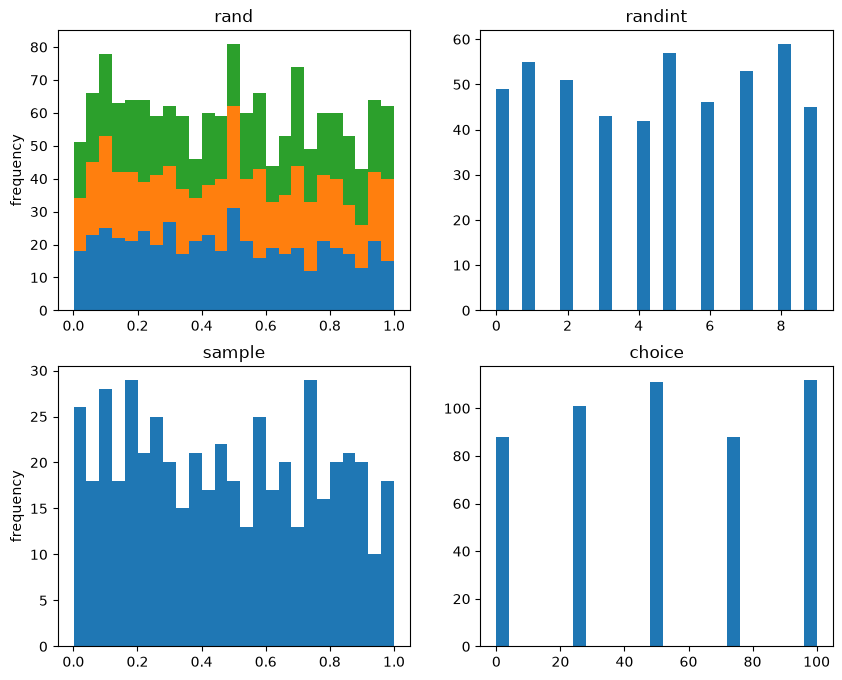

In [9]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(10,8))

ax1.hist(rn1, bins=25, stacked=True)
ax1.set_title('rand')
ax1.set_ylabel('frequency')

ax2.hist(rn2, bins=25)
ax2.set_title('randint')

ax3.hist(rn3, bins=25)
ax3.set_title('sample')
ax3.set_ylabel('frequency')

ax4.hist(rn4, bins=25)
ax4.set_title('choice')

plt.show()

In [10]:
sample_size = 500

rn1 = npr.standard_normal(sample_size)

rn2 = npr.normal(100, 20, sample_size)

rn3 = npr.chisquare(df=0.5, size=sample_size)

rn4 = npr.poisson(lam=1.0, size=sample_size)

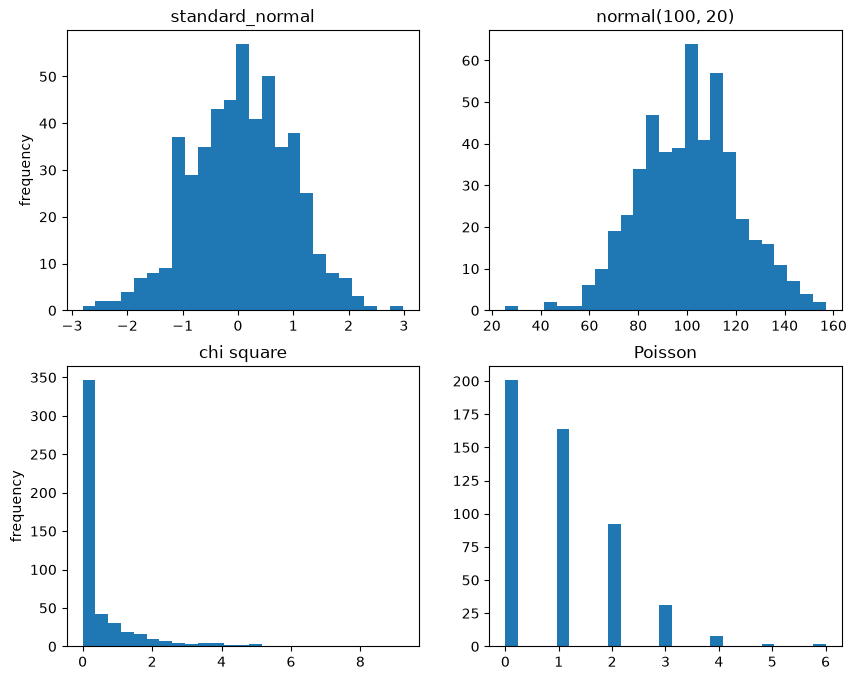

In [11]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

ax1.hist(rn1, bins=25)
ax1.set_title('standard_normal')
ax1.set_ylabel('frequency')

ax2.hist(rn2, bins=25)
ax2.set_title('normal(100, 20)')

ax3.hist(rn3, bins=25)
ax3.set_title('chi square')
ax3.set_ylabel('frequency')

ax4.hist(rn4, bins=25)
ax4.set_title('Poisson')

plt.show()

## 12.2 시뮬레이션

### 12.2.1 확률 변수

**블랙-숄즈-머튼 모형에서의 미래의 주가 시뮬레이션**
- 미래의 특정 시점 $T$에서의 주가 $S_T$를 현 시점의 주가 $S_0$와 수식으로 계산.
- $S_T = S_0 \exp \left( \left( r - \dfrac{1}{2} \sigma^2 \right) T + \sigma \sqrt{T} z \right)$

    - $S_T$: 날짜 $T$에서의 주가
    - $r$: 무위험 단기 이자율
    - $\sigma$: 주가 $S$에 대한 고정 변동성(수익률의 표준편차)
    - $z$: 표준정규분포를 따르는 확률 변수


In [12]:
S0 = 100
r = 0.05
sigma = 0.25
T = 2.0
I = 10000
ST1 = S0 * np.exp((r - 0.5 * sigma * sigma) * T + sigma * math.sqrt(T) * npr.standard_normal(I))

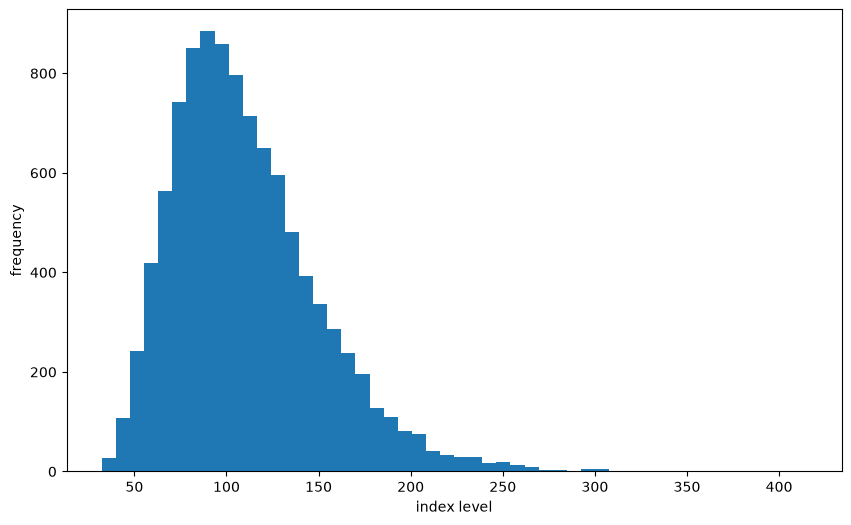

In [13]:
plt.figure(figsize=(10, 6))

plt.hist(ST1, bins=50)

plt.xlabel('index level')
plt.ylabel('frequency')

plt.show()

**로그 정규분포로 정의된 확률변수**
1. 정규분포
- 표준정규분포 난수를 뽑아서 직접 기하 브라운 운동의 만기 가격을 계산.

2. 로그 정규분포
- 어떤 확률변수에 로그를 취했을 때 정규분포가 되는 분포, $\ln X \sim N(\mu, \sigma^2)$

- $X = e^Y, Y \sim N(\mu, \sigma^2)$
- 정규분포를 따르는 값 $Y$에 지수함수 $e^Y$를 씌운 값이 로그 정규분포를 따름

- `np.random.lognormal(mean, sigma, size)`를 사용해서 바로 로그 정규분포 난수를 뽑음.
- $=$ `np.exp(np.random.normal(mean, sigma))`

In [14]:
ST2 = S0 * npr.lognormal((r - 0.5 * sigma * sigma) * T, sigma * math.sqrt(T), size=I)

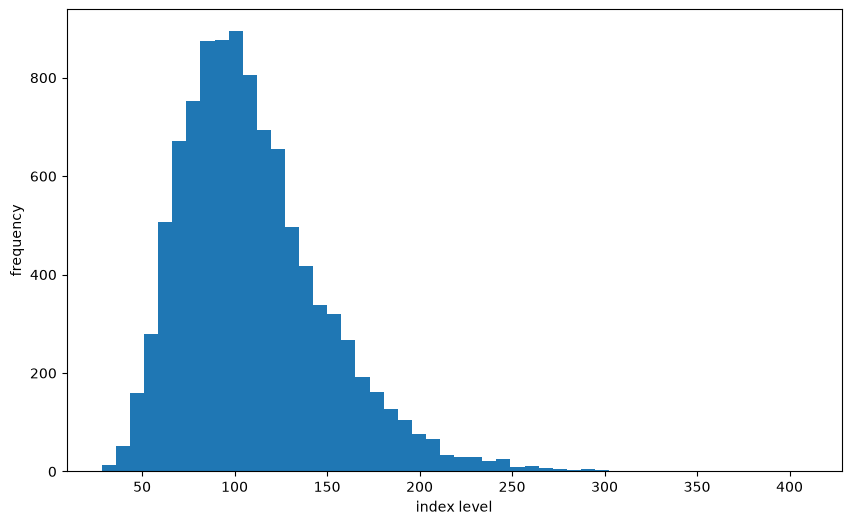

In [15]:
plt.figure(figsize=(10,6))

plt.hist(ST2, bins=50)

plt.xlabel('index level')
plt.ylabel('frequency')

plt.show()

- `scipy.stats` 서브패키지
- `scipy.stats.descrbe()`: 데이터에 대한 중요 통계를 반환

In [16]:
import scipy.stats as scs

In [17]:
def print_statistics(a1, a2):
    ''' 선택된 통계값을 출력

    인수
    ==========
    a1, a2: ndarray 객체
    시뮬레이션에서 나온 결과 객체
    '''
    sta1 = scs.describe(a1)
    sta2 = scs.describe(a2)

    print(f'{'statistic':14s} {'data set 1':14s} {'data set 2':14s}')
    print(45 * "-")
    print(f'{'size':14s} {sta1[0]:14.3f} {sta2[0]:14.3f}')
    print(f'{'min':14s} {sta1[1][0]:14.3f} {sta2[1][0]:14.3f}')
    print(f'{'max':14s} {sta1[1][1]:14.3f} {sta2[1][1]:14.3f}')
    print(f'{'mean':14s} {sta1[2]:14.3f} {sta2[2]:14.3f}')
    print(f'{'std':14s} {np.sqrt(sta1[3]):14.3f} {np.sqrt(sta2[3]):14.3f}')
    print(f'{'skew':14s} {sta1[4]:14.3f} {sta2[4]:14.3f}')
    print(f'{'kurtosis':14s} {sta1[5]:14.3f} {sta2[5]:14.3f}')

In [18]:
print_statistics(ST1, ST2)

statistic      data set 1     data set 2    
---------------------------------------------
size                10000.000      10000.000
min                    32.327         28.230
max                   414.825        409.110
mean                  110.730        110.431
std                    40.300         39.878
skew                    1.122          1.115
kurtosis                2.438          2.217


### 12.2.2 확률 과정

- 확률 과정: 확률 변수의 수열
- 확률 과정을 시뮬레이션 = 확률 변수를 반복해서 시뮬레이션
- 각 단계의 샘플이 독립적이지 않고 이전의 결과들에 의존한다는 차이점.
- **마코프(Markov) 특성**: 미래 값이 바로 전의 과거 값에만 의존하고 그보다 더 과거의 값이나 전체 경로에는 의존하지 않음.
- **무기억성(memoryless) 확률 과정**


**기하 브라운 운동 모형**

블랙-숄즈-머튼 모형: 아래 확률 미분방정식(SDE, stochastic differential equation)을 따르는 동적인 형태의 모형

확률 미분방정식: **기하 브라운 운동**
- $d S_t = r S_t dt + \sigma S_t dZ_t$

    - $Z_t$는 표준 브라운 운동 과정의 값
    - $S_t$값은 로그 정규분포를 따르고,
    - 수익률 $\dfrac{dS_t}{S_t}$는 정규분포를 따름.

확률 미분방적식을 오일러 방식(Euler scheme)으로 정확히 이산화(discretization)할 수 있음.
- $S_t = S_{t - \Delta t} \exp \left( \left( r - \dfrac{1}{2} \sigma^2 \right) \Delta t + \sigma \sqrt{\Delta t} z_t \right)$

    - $\Delta t$: 고정된 시간 이산화 간격,
    - $z_t$: 정규분포를 따르는 확률 변수

In [19]:
I = 10000 # 시뮬레이션 경로의 개수
M = 50 # 이산화 구간의 개수
dt = T / M # 연 단위 시간 길이
S = np.zeros((M + 1, I)) # 주가 수준 2차원 ndarray 객체
S[0] = S0 # 초기 시간 t=0에서의 주가
for t in range(1, M + 1):
    S[t] = S[t-1] * np.exp((r - 0.5 * sigma ** 2) * dt + sigma * math.sqrt(dt) * npr.standard_normal(I))
    # 반-벡터화 표현식으로 나타낸 시뮬레이션, 루프는 시간 t=1에서 t=T까지의 반복

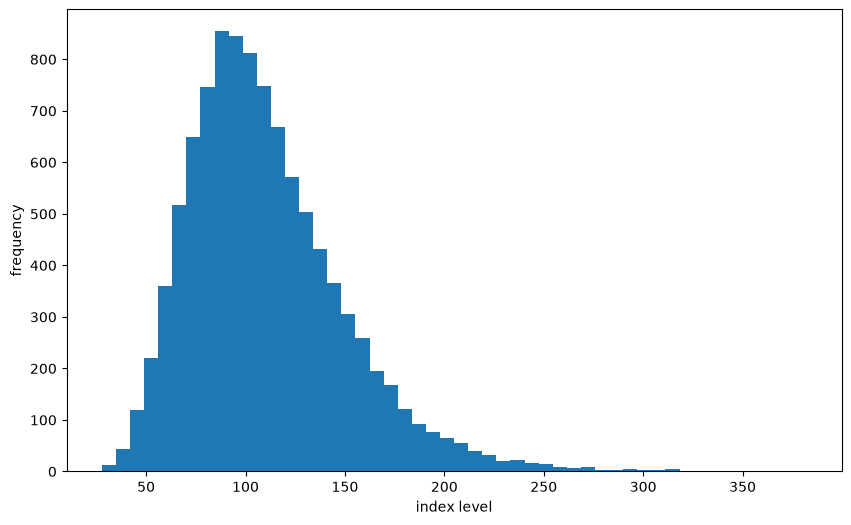

In [20]:
plt.figure(figsize=(10, 6))

plt.hist(S[-1], bins=50)

plt.xlabel('index level')
plt.ylabel('frequency')

plt.show()

In [21]:
print_statistics(S[-1], ST2)

statistic      data set 1     data set 2    
---------------------------------------------
size                10000.000      10000.000
min                    27.746         28.230
max                   382.096        409.110
mean                  110.423        110.431
std                    39.179         39.878
skew                    1.069          1.115
kurtosis                2.028          2.217


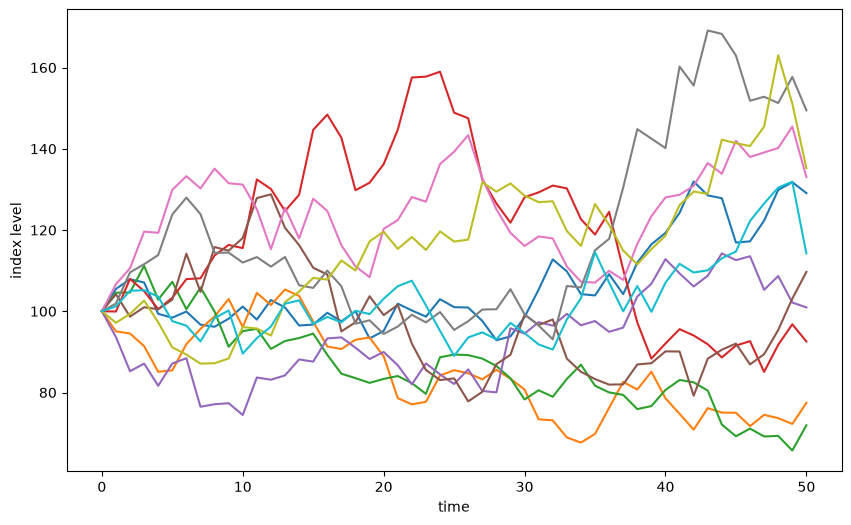

In [22]:
plt.figure(figsize=(10,6))

plt.plot(S[:, :10], lw=1.5)

plt.xlabel('time')
plt.ylabel('index level')

plt.show()

**제곱근 확산 모형**

**평균 회귀 과정(mean-reverting process)**: 단기 이자율이나 변동성 모형에서 사용

**제곱근 확산(square-root diffusion) 모형**: 평균 회귀 과정에서 가장 널리 사용되는 모형

제곱근 확산 확률 미분방정식

- $dx_t = \kappa ( \theta - x_t ) dt + \sigma \sqrt{x_t} d Z_t$

    - $x_t$: 시간 $t$에서의 확률 과정 값

    - $\kappa$: 평균 회귀계수

    - $\theta$: 확률 과정의 장기 평균

    - $\sigma$: 고정 변동성

    - $Z_t$: 표준 브라운 운동